In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from unidecode import unidecode  

In [3]:
df = pd.read_parquet(r"C:\Users\Mateus Monteleone\Projects\ic\data\tweets_base_normalizados.parquet")

In [4]:
da = df

In [5]:
da.head()

,full_text,clean_text
0,se o lula ganhar eu quero uma roda de beijo co...,se o lula ganhar eu quero uma roda de beijo co...
1,@ixslorena LULA PRESIDENTE HOJE,@USER LULA PRESIDENTE HOJE
2,mãe morrendo de alegria na carreata do Lula,mãe morrendo de alegria na carreata do Lula
3,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,@USER AVISA QUE MEU PAI LULA VAI GANHAR PRIMEI...
4,@indieoffw O RJ elegendo castro e juram que va...,@USER O RJ elegendo castro e juram que vai dar...


In [6]:
def analiseTermosEconomicosExpandida(df):
    palavras_chave_economicas = [
        'emprego','desemprego','bolsa','bolsa de valores','mercado','mercado financeiro',
        'inflacao','inflação','renda','dolar','dólar','cambio','câmbio','taxa de cambio','taxa de câmbio',
        'juros','taxa de juros','industria','indústria','salario','salarios','salários','valor',
        'auxilio','auxílio','banco','bancos','credito','crédito','desigual','desigualdade',
        'empreendedor','empreendedorismo','financeiro','financas','finanças','financa',
        'financiamento','financiar','impostos','imposto','economia','igualdade',
        'pib','produto interno bruto','recessao','recessão','crescimento','deflacao','deflação',
        'superavit','superávit','deficit','déficit','orcamento','orçamento','orcamento publico','orçamento público',
        'gasto publico','gasto público','divida','dívida','divida publica','dívida pública',
        'investimento','investimentos','investidor','investidores','acoes','ações','acao','ação',
        'derivativos','derivativo','futuros',
        'b3','selic','copom','tesouro','tesouro direto','banco central',
        'custo de vida','pobreza','renda minima','renda mínima','salario minimo','salário mínimo',
        'mercado de trabalho','carteira assinada','clt','educacao','educação'
    ]

    # remove duplicates while preserving order
    palavras_chave_economicas = list(dict.fromkeys(palavras_chave_economicas))

    # normalize for consistent matching (optional but recommended if clean_text is de-accented)
    kws_norm = [unidecode(k.lower()) for k in palavras_chave_economicas]

    padrao_economico = re.compile(
        r'\b(?:' + '|'.join(map(re.escape, kws_norm)) + r')\b',
        flags=re.IGNORECASE
    )

    serie = df["clean_text"].astype("string").fillna("")
    serie_norm = serie.map(lambda s: unidecode(s.lower()))

    mask_economico = serie_norm.str.contains(padrao_economico, na=False)
    df_economico = df.loc[mask_economico].copy()

    contador = Counter()
    for texto in serie_norm[mask_economico]:
        encontrados = set(padrao_economico.findall(texto))
        contador.update(encontrados)

    contagens_df = pd.Series(contador).sort_values(ascending=False)

    contagens_df.plot(kind="bar", figsize=(12,6))
    plt.title("Frequência de termos econômicos")
    plt.ylabel("Número de tweets")
    plt.tight_layout()
    plt.show()

    return df_economico

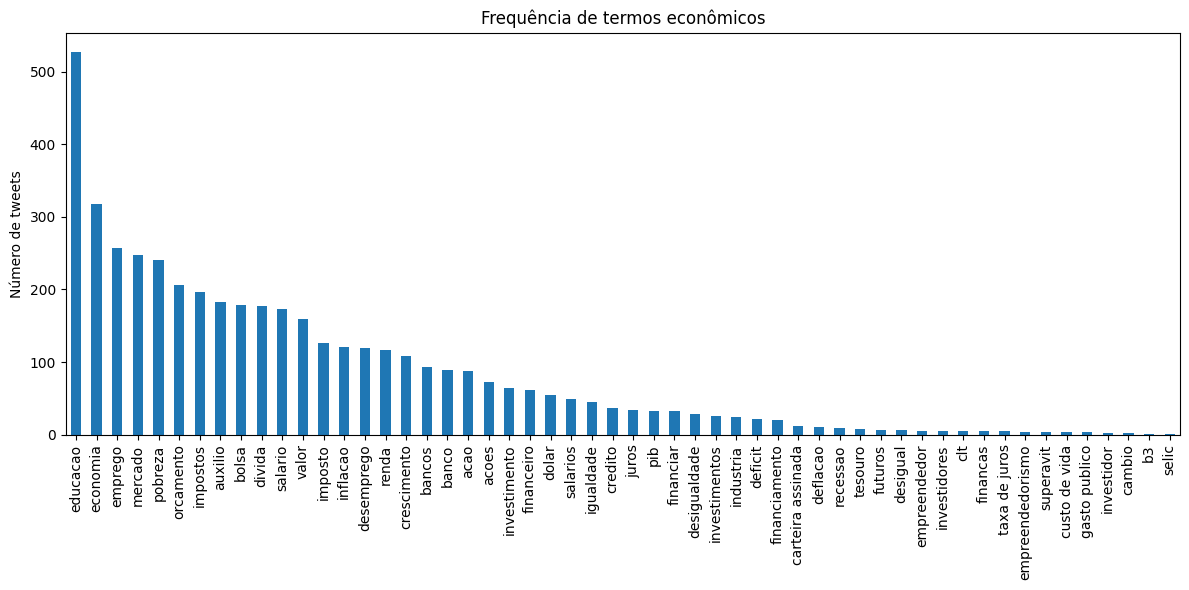

In [7]:
df_economico = analiseTermosEconomicosExpandida(da)

In [8]:
df_economico.head()

,full_text,clean_text
37,@TorresBetotada @PaulinhoSerra Estudou pra ach...,@USER @USER Estudou pra achar que a OLIGARQUIA...
40,@jairbolsonaro ele vai dançar tão mal mas elev...,@USER ele vai dançar tão mal mas elevou o país...
94,@GuajajaraSonia Puff!!! Brasileiros Sao Tao il...,@USER Puff ! ! ! Brasileiros Sao Tao iludidos ...
110,@JornalOGlobo Maior furada essas pesquisas a G...,@USER Maior furada essas pesquisas a Globo anu...
111,@CentralEleicoes 1 DIA PRO 13 Por mais educaçã...,"@USER 1 DIA PRO 13 Por mais educação , saúde ,..."


In [9]:
len(df_economico)

3804

In [18]:
df_economico.to_parquet(
    "tweets_economicos.parquet",
    index=False
)

In [10]:
df_nao_economico = df.loc[~df.index.isin(df_economico.index)]

In [11]:
df_nao_economico.head()

,full_text,clean_text
0,se o lula ganhar eu quero uma roda de beijo co...,se o lula ganhar eu quero uma roda de beijo co...
1,@ixslorena LULA PRESIDENTE HOJE,@USER LULA PRESIDENTE HOJE
2,mãe morrendo de alegria na carreata do Lula,mãe morrendo de alegria na carreata do Lula
3,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,@USER AVISA QUE MEU PAI LULA VAI GANHAR PRIMEI...
4,@indieoffw O RJ elegendo castro e juram que va...,@USER O RJ elegendo castro e juram que vai dar...


In [23]:
df_nao_economico.to_parquet(
    "tweets_nao_economicos.parquet",
    index=False
)

In [12]:
len(df_nao_economico)

189150

In [30]:
sample_econ = df_economico.sample(250, random_state=42)
sample_nao = df_nao_economico.sample(250, random_state=42)

In [31]:
sample_econ = sample_econ.copy()
sample_econ["is_economic"] = 1

sample_nao = sample_nao.copy()
sample_nao["is_economic"] = 0

In [32]:
df_manual = pd.concat([sample_econ, sample_nao], ignore_index=True)

In [33]:
df_manual["sentiment_manual"] = None


In [34]:
df_manual.head()

,full_text,clean_text,is_economic,sentiment_manual
0,@mario_heringer @cirogomes É CIRO NO SEGUNDO T...,"@USER @USER É CIRO NO SEGUNDO TURNO , PARA NOS...",1,None
1,"Pensem bem antes de votar. Amanhã, sentenciare...","Pensem bem antes de votar . Amanhã , sentencia...",1,None
2,Eu discutindo com painha p ver qm ganha lula o...,Eu discutindo com painha p ver qm ganha lula o...,1,None
3,Também não há como esquecer o apoio de parte d...,Também não há como esquecer o apoio de parte d...,1,None
4,@ptbrasil @LulaOficial Lula 13 para voltar a a...,"@USER @USER Lula 13 para voltar a alegria , co...",1,None


In [35]:
len(df_manual)

500

In [26]:
df_manual.to_parquet(
    "df_rotulação_manual.parquet",
    index=False
)